Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# ---------- Load the five cleaned datasets ----------
ethiopia = pd.read_csv('../data/ethiopia_clean.csv')
kenya = pd.read_csv('../data/kenya_clean.csv')
nigeria = pd.read_csv('../data/nigeria_clean.csv')
sudan = pd.read_csv('../data/sudan_clean.csv')
tanzania = pd.read_csv('../data/tanzania_clean.csv')

# Add a 'Country' label column to each
ethiopia['country']  = 'Ethiopia'
kenya['country'] = 'Kenya'
nigeria['country'] = 'Nigeria'
sudan['country'] = 'Sudan'
tanzania['country'] = 'Tanzania'

# Combine into one big DataFrame
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)

print(f'Total rows: {len(df)}')
df.head()

Total rows: 19881


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [4]:
#Numeric columns describe
df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].describe()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
count,19881.000000,19881.000000,19881.000000,19881.000000,19881.000000,19881.000000,19881.000000
mean,23.777334,29.253226,19.269265,2.194183,65.327046,2.981626,4.251572
std,5.367638,5.138066,6.516785,3.971074,21.965436,1.162123,1.390426
min,10.420000,15.650000,2.460000,0.000000,4.690000,0.460000,0.790000
25%,19.510000,26.770000,13.510000,0.010000,55.680000,2.090000,3.160000
50%,25.230000,28.760000,22.050000,0.380000,72.500000,2.830000,4.200000
75%,27.560000,30.760000,25.270000,2.470000,82.330000,3.810000,5.240000
max,37.990000,45.960000,32.170000,26.960000,93.610000,7.260000,8.790000


/tmp/ipykernel_37317/4263102569.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_country = df.set_index('date').groupby('country')['T2M'].resample('M').mean().reset_index()


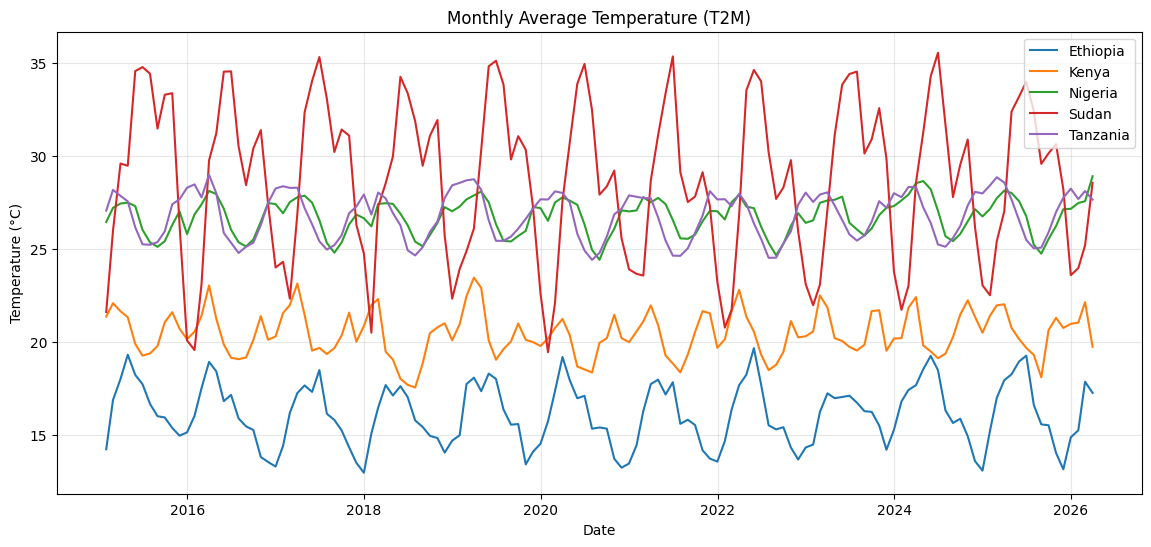

In [17]:
df['date'] = pd.to_datetime(df['date'])
monthly_avg_country = df.set_index('date').groupby('country')['T2M'].resample('M').mean().reset_index()

plt.figure(figsize=(14,6))

for country in monthly_avg_country['country'].unique():
    subset = monthly_avg_country[monthly_avg_country['country'] == country]
    plt.plot(subset['date'], subset['T2M'], label=country)

plt.title('Monthly Average Temperature (T2M)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Sumaary table comparing mean, median, standard deviation
df_stats_country = df_all.groupby('country')['T2M'].agg(['mean', 'median', 'std'])
print(df_stats_country)

In [6]:
# Sumaary table comparing mean, median, standard deviation
metrics = ['T2M']

summary = df.groupby('country')[metrics].agg(['mean', 'median', 'std']).round(2)

# Flatten column names for readability
summary.columns = [f'{col}_{stat}' for col, stat in summary.columns]

print('Summary Statistics per Country:')
display(summary)

Summary Statistics per Country:


,T2M_mean,T2M_median,T2M_std
country,,,
Ethiopia,16.10,16.06,1.88
Kenya,20.45,20.39,1.42
Nigeria,26.74,26.91,1.07
Sudan,28.79,29.23,4.69
Tanzania,26.80,27.00,1.33


Precipitation Variablility Comparision

/tmp/ipykernel_37317/1131145685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


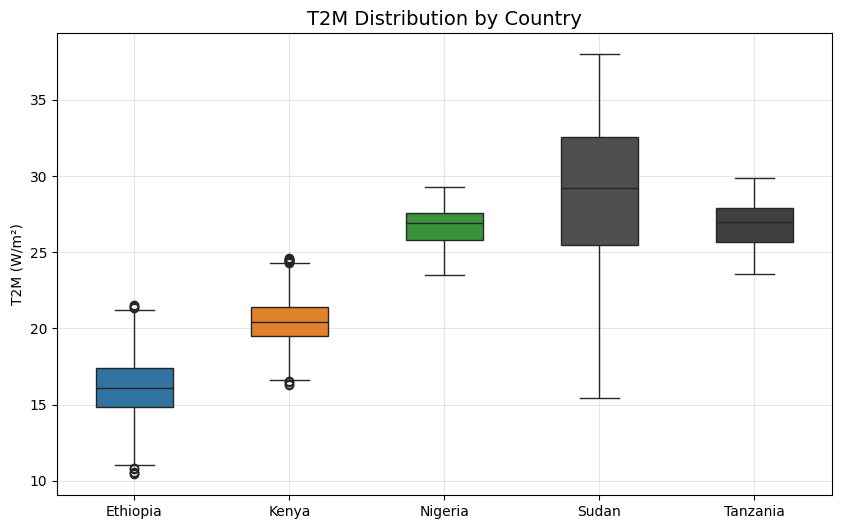

In [9]:
colors = {'Ethiopia': '#1f77b4', 'Kenya': '#ff7f0e', 'Nigeria': '#2ca02c', 'Tanzania': '#3F3F3F', 'Sudan': '#4F4F4F'}

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x='country',
        y=metric,
        palette=colors,
        width=0.5
    )
    plt.title(f'{metric} Distribution by Country', fontsize=14)
    plt.ylabel(f'{metric} (W/m²)')
    plt.xlabel('')
    plt.grid(True, alpha=0.3)
    plt.show()

In [10]:
# Sumaary table comparing mean, median, standard deviation
metrics = ['PRECTOTCORR']

summary = df.groupby('country')[metrics].agg(['mean', 'median', 'std']).round(2)

# Flatten column names for readability
summary.columns = [f'{col}_{stat}' for col, stat in summary.columns]

print('Summary Statistics per Country:')
display(summary)

Summary Statistics per Country:


,PRECTOTCORR_mean,PRECTOTCORR_median,PRECTOTCORR_std
country,,,
Ethiopia,3.02,0.76,4.57
Kenya,1.10,0.36,1.76
Nigeria,3.65,1.88,4.60
Sudan,0.32,0.00,1.12
Tanzania,2.94,0.61,4.97


In [37]:
# tHE NUMBER OF DAYS PER YEAR WHERE MAXIMUM TEMP > 35
hot_days = df[df['T2M'] > 35]
hot_result = hot_days.groupby(['country', 'YEAR']).size().reset_index(name='hot_days')
print(hot_result)

   country  YEAR  hot_days
0    Sudan  2015        41
1    Sudan  2016        26
2    Sudan  2017        34
3    Sudan  2018        15
4    Sudan  2019        39
5    Sudan  2020        29
6    Sudan  2021        29
7    Sudan  2022        20
8    Sudan  2023        29
9    Sudan  2024        39
10   Sudan  2025        24


In [36]:
# THE NUMBER OF CONSECUTIVE DRY DAYS PER YEAR WHERE DAILY PRECIPITATION < 1
hot_days = df[df['PRECTOTCORR'] < 1]
dry_result = hot_days.groupby(['country', 'YEAR']).size().reset_index(name='dry_days')
print(dry_result)

     country  YEAR  dry_days
0   Ethiopia  2015       215
1   Ethiopia  2016       170
2   Ethiopia  2017       177
3   Ethiopia  2018       193
4   Ethiopia  2019       185
5   Ethiopia  2020       189
6   Ethiopia  2021       191
7   Ethiopia  2022       206
8   Ethiopia  2023       170
9   Ethiopia  2024       168
10  Ethiopia  2025       197
11  Ethiopia  2026        64
12     Kenya  2015       248
13     Kenya  2016       260
14     Kenya  2017       279
15     Kenya  2018       227
16     Kenya  2019       240
17     Kenya  2020       211
18     Kenya  2021       267
19     Kenya  2022       279
20     Kenya  2023       255
21     Kenya  2024       239
22     Kenya  2025       253
23     Kenya  2026        52
24   Nigeria  2015       123
25   Nigeria  2016       136
26   Nigeria  2017       132
27   Nigeria  2018       136
28   Nigeria  2019       105
29   Nigeria  2020       149
30   Nigeria  2021       139
31   Nigeria  2022       123
32   Nigeria  2023       103
33   Nigeria  

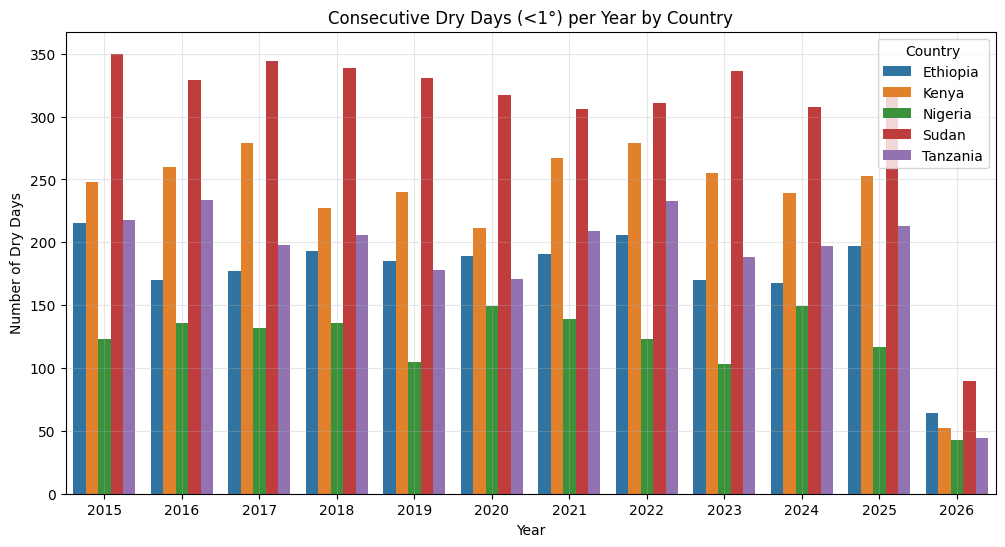

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=dry_result,
    x='YEAR',
    y='dry_days',
    hue='country'
)

plt.title('Consecutive Dry Days (<1°) per Year by Country')
plt.ylabel('Number of Dry Days')
plt.xlabel('Year')
plt.legend(title='Country')
plt.grid(True, alpha=0.3)
plt.show()

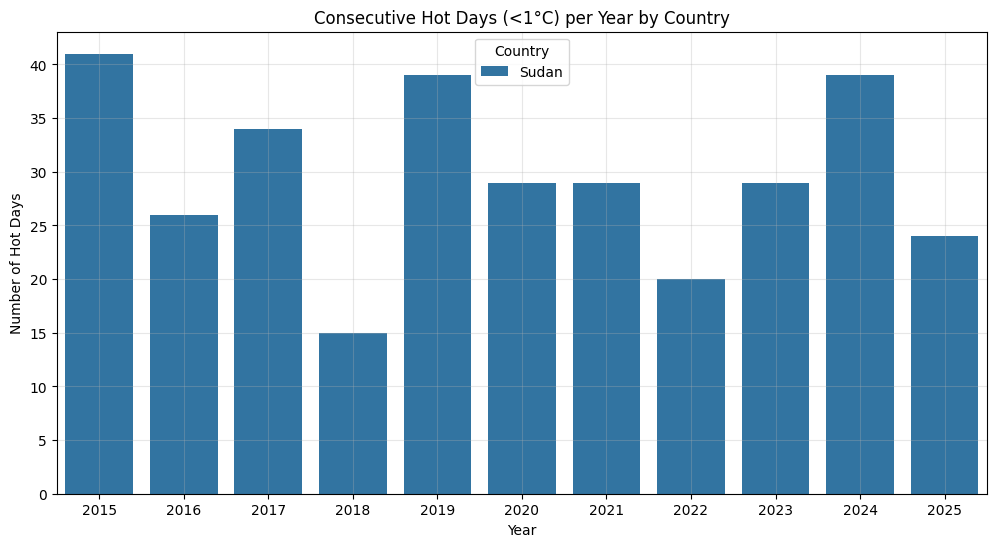

In [41]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=hot_result,
    x='YEAR',
    y='hot_days',
    hue='country'
)

plt.title('Consecutive Hot Days (<1°C) per Year by Country')
plt.ylabel('Number of Hot Days')
plt.xlabel('Year')
plt.legend(title='Country')
plt.grid(True, alpha=0.3)
plt.show()

- Climate Vulnerability Ranking                    	
    - 1	Sudan	               
    - 2	Ethiopia	            
    - 3	Kenya	                
    - 4	Tanzania	                	
    - 5	Nigeria	                  



1. Sudan is warming the fastest, with temperatures rising ~0.4°C per decade. The trend suggests a shift toward permanent aridity, where extreme heatwaves and nearly year-round dry days make natural soil recovery increasingly impossible.

2. Kenya and Ethiopia exhibit the most unstable patterns, showing high year-to-year volatility in dry days due to shifting ocean cycles. 

3. The frequency of overlapping heat and drought reveals a loss of climate resilience, where ecosystems no longer have time to recover between shocks. This suggests a transition toward permanent environmental stress, leading to irreversible soil degradation and the exhaustion of critical water sources.

4. Ethiopia acts as a "cool island" with the lowest baseline temperatures due to its high altitude. However, it suffers from greater volatility than its neighbors, experiencing more extreme year-to-year swings between drought and heavy rainfall.

5. Ethiopia should champion Sudan, as it faces the region's most extreme thermal stress and near-permanent aridity (350+ dry days/year). The data highlights Sudan as a "hotspot" where warming is accelerating twice as fast as the global average, making it the most critical case for urgent Loss and Damage funding.